In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from analysis.utils import load_sweep_metadata, load_data, compute_success

In [3]:
df_metadata = load_sweep_metadata(
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-19-control-cheetah-velocity-probe",
    json_file_name="episode_metadata.json",
)

df = load_data(
    df_metadata,
    episode_file_name="episode_data.pkl",
)

Dirs in /home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/25-12-19-control-cheetah-velocity-probe: 100%|██████████| 266/266 [00:03<00:00, 85.23it/s]


Found 265 configurations
Found 265 configurations


100%|██████████| 265/265 [00:03<00:00, 81.70it/s]


In [16]:
df = df[df['seed'] == 0]
df = df[df['config_start_step'] == 0]
df.shape

(126, 26)

In [17]:
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())
z = np.concatenate(df['latent_states'].tolist())
obs = np.concatenate(df['observations'].tolist())
actions = np.concatenate(df['actions'].tolist())
z = np.concatenate(df['latent_states'].tolist())

positions = obs[:, :8]  # qpos[1:]
velocities = obs[:, 8:]  # qvel[:]  -> 9 dims
vel_torso = velocities[:, 0][:, None]

z.shape, obs.shape, actions.shape, positions.shape, velocities.shape, vel_torso.shape


((63000, 512), (63000, 17), (63000, 6), (63000, 8), (63000, 9), (63000, 1))

In [18]:
df['avg_vel_torso'] = df['observations'].apply(
    lambda x: np.array(x)[:, 8].mean())

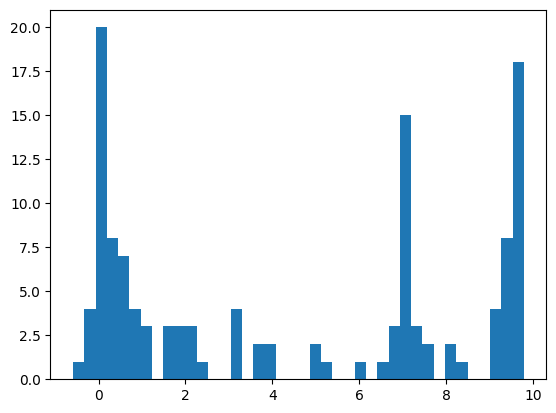

In [21]:
plt.hist(df['avg_vel_torso'], bins=40)
plt.show()

In [ ]:
# Get unique direction strings

direction_order = ['random_0', 'random_1', 'random_2', 'position', 'actions']
direction_order = [
    'x_t+0', 'x_t+10', 'x_t+20', 'x_t+30', 'x_t+40', 'x_t+50', 'delta_10',
    'delta_20', 'delta_30', 'delta_40', 'delta_50', 'position', 'actions',
    'random_0', 'random_1', 'random_2'
]
direction_strs = direction_order
n_directions = len(direction_strs)
y_var = 'total_position_change_midepisode'

# Create subplots: 3 columns, calculate rows needed
n_cols = 3
n_rows = (n_directions + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows), sharey=True)
axes = axes.flatten() if n_directions > 1 else [axes]

for idx, direction_str in enumerate(direction_strs):
    ax1 = axes[idx]

    df_to_plot = df[df['config_direction_str'] == direction_str]

    # Group by alpha
    grouped = df_to_plot.groupby('config_magnitude')

    # Left y-axis:
    ax1.set_xlabel('α', fontsize=14)
    ax1.set_ylabel('Average total position change', fontsize=14)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # Plot one line per seed
    for seed in df_to_plot['config_seed'].unique():
        seed_data = df_to_plot[df_to_plot['config_seed'] == seed].sort_values(
            'config_magnitude')
        ax1.plot(seed_data['config_magnitude'],
                 seed_data[y_var],
                 color='pink',
                 marker='o',
                 alpha=0.5,
                 linewidth=1)

    # Plot mean with error bars (95% CI)
    alphas = []
    means = []
    ci_lower = []
    ci_upper = []

    for alpha, group in grouped:
        alphas.append(alpha)
        mean_val = group[y_var].mean()
        means.append(mean_val)
        std_val = group[y_var].std()
        n = len(group)
        ci = 1.96 * std_val / np.sqrt(n)  # 95% CI
        ci_lower.append(mean_val - ci)
        ci_upper.append(mean_val + ci)

    ax1.errorbar(alphas,
                 means,
                 yerr=[
                     np.array(means) - np.array(ci_lower),
                     np.array(ci_upper) - np.array(means)
                 ],
                 fmt='o-',
                 color='black',
                 linewidth=2,
                 markersize=8,
                 capsize=5,
                 capthick=2,
                 label='Mean ± 95% CI')

    ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    ax1.set_xticks(alphas)
    ax1.set_xticklabels([str(a) for a in alphas])
    ax1.grid(True, alpha=0.3)
    #ax1.set_ylim(-1.75, 1.75)

    # Right y-axis: success rate
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Success Rate', fontsize=14, color='blue')
    ax2.set_ylim(-0.05, 1.05)

    # Calculate success rate for each alpha
    success_rates = []
    for alpha, group in grouped:
        success_rate = group['success'].mean()
        success_rates.append(success_rate)

    ax2.plot(alphas,
             success_rates,
             'o-',
             color='blue',
             linewidth=2,
             markersize=8,
             label='Success Rate')
    ax2.tick_params(axis='y', labelcolor='blue', labelsize=12)

    # Title
    ax1.set_title(direction_str, fontsize=16)

    # Legend (only for first plot)
    if idx == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2,
                   labels1 + labels2,
                   loc='upper left',
                   fontsize=12)

# Hide any unused subplots
for idx in range(n_directions, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
sns.despine(top=True, right=False)
plt.show()

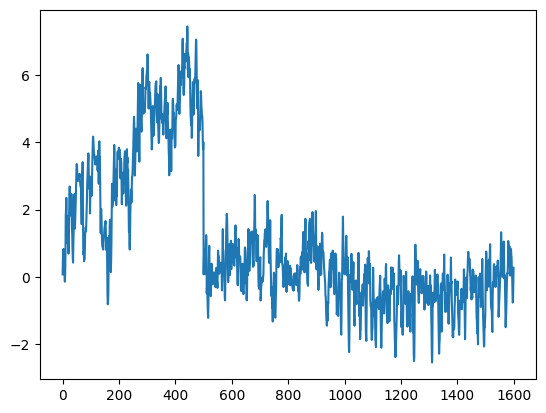

In [23]:
plt.plot(vel_torso[:1600])

In [ ]:
# df['config_hinge_1_value_degrees'] = np.degrees(df['config_hinge_1_value'])
# df['hinge_str'] = df['config_hinge_1_value_degrees'].round(0).astype(str)

# for dim in range(5):
#     df[f'average_dim_{dim}'] = df['observations'].apply(
#         lambda x: np.mean(np.array(x)[:, dim]))

# df['total_position_change'] = df['observations'].apply(
#     lambda x: np.array(x)[-1, 0] - np.array(x)[0, 0])

# df['total_position_change_midepisode'] = df['observations'].apply(
#     lambda x: np.array(x)[-300, 0] - np.array(x)[0, 0])

# df['cumulative_abs_position_change'] = df['observations'].apply(
#     lambda x: np.sum(np.abs(np.diff(np.array(x)[:, 0]))))

# df['cumulative_position_change'] = df['observations'].apply(
#     lambda x: np.sum(np.diff(np.array(x)[:, 0])))

In [28]:
df['config_direction_str'].unique()

array(['delta_20', 'x_t+0', 'x_t+40', 'x_t+10', 'x_t+5', 'x_t+30',
       'delta_10', 'delta_5', 'x_t+20', 'random_0', 'delta_30',
       'random_1', 'random_2', 'delta_40'], dtype=object)

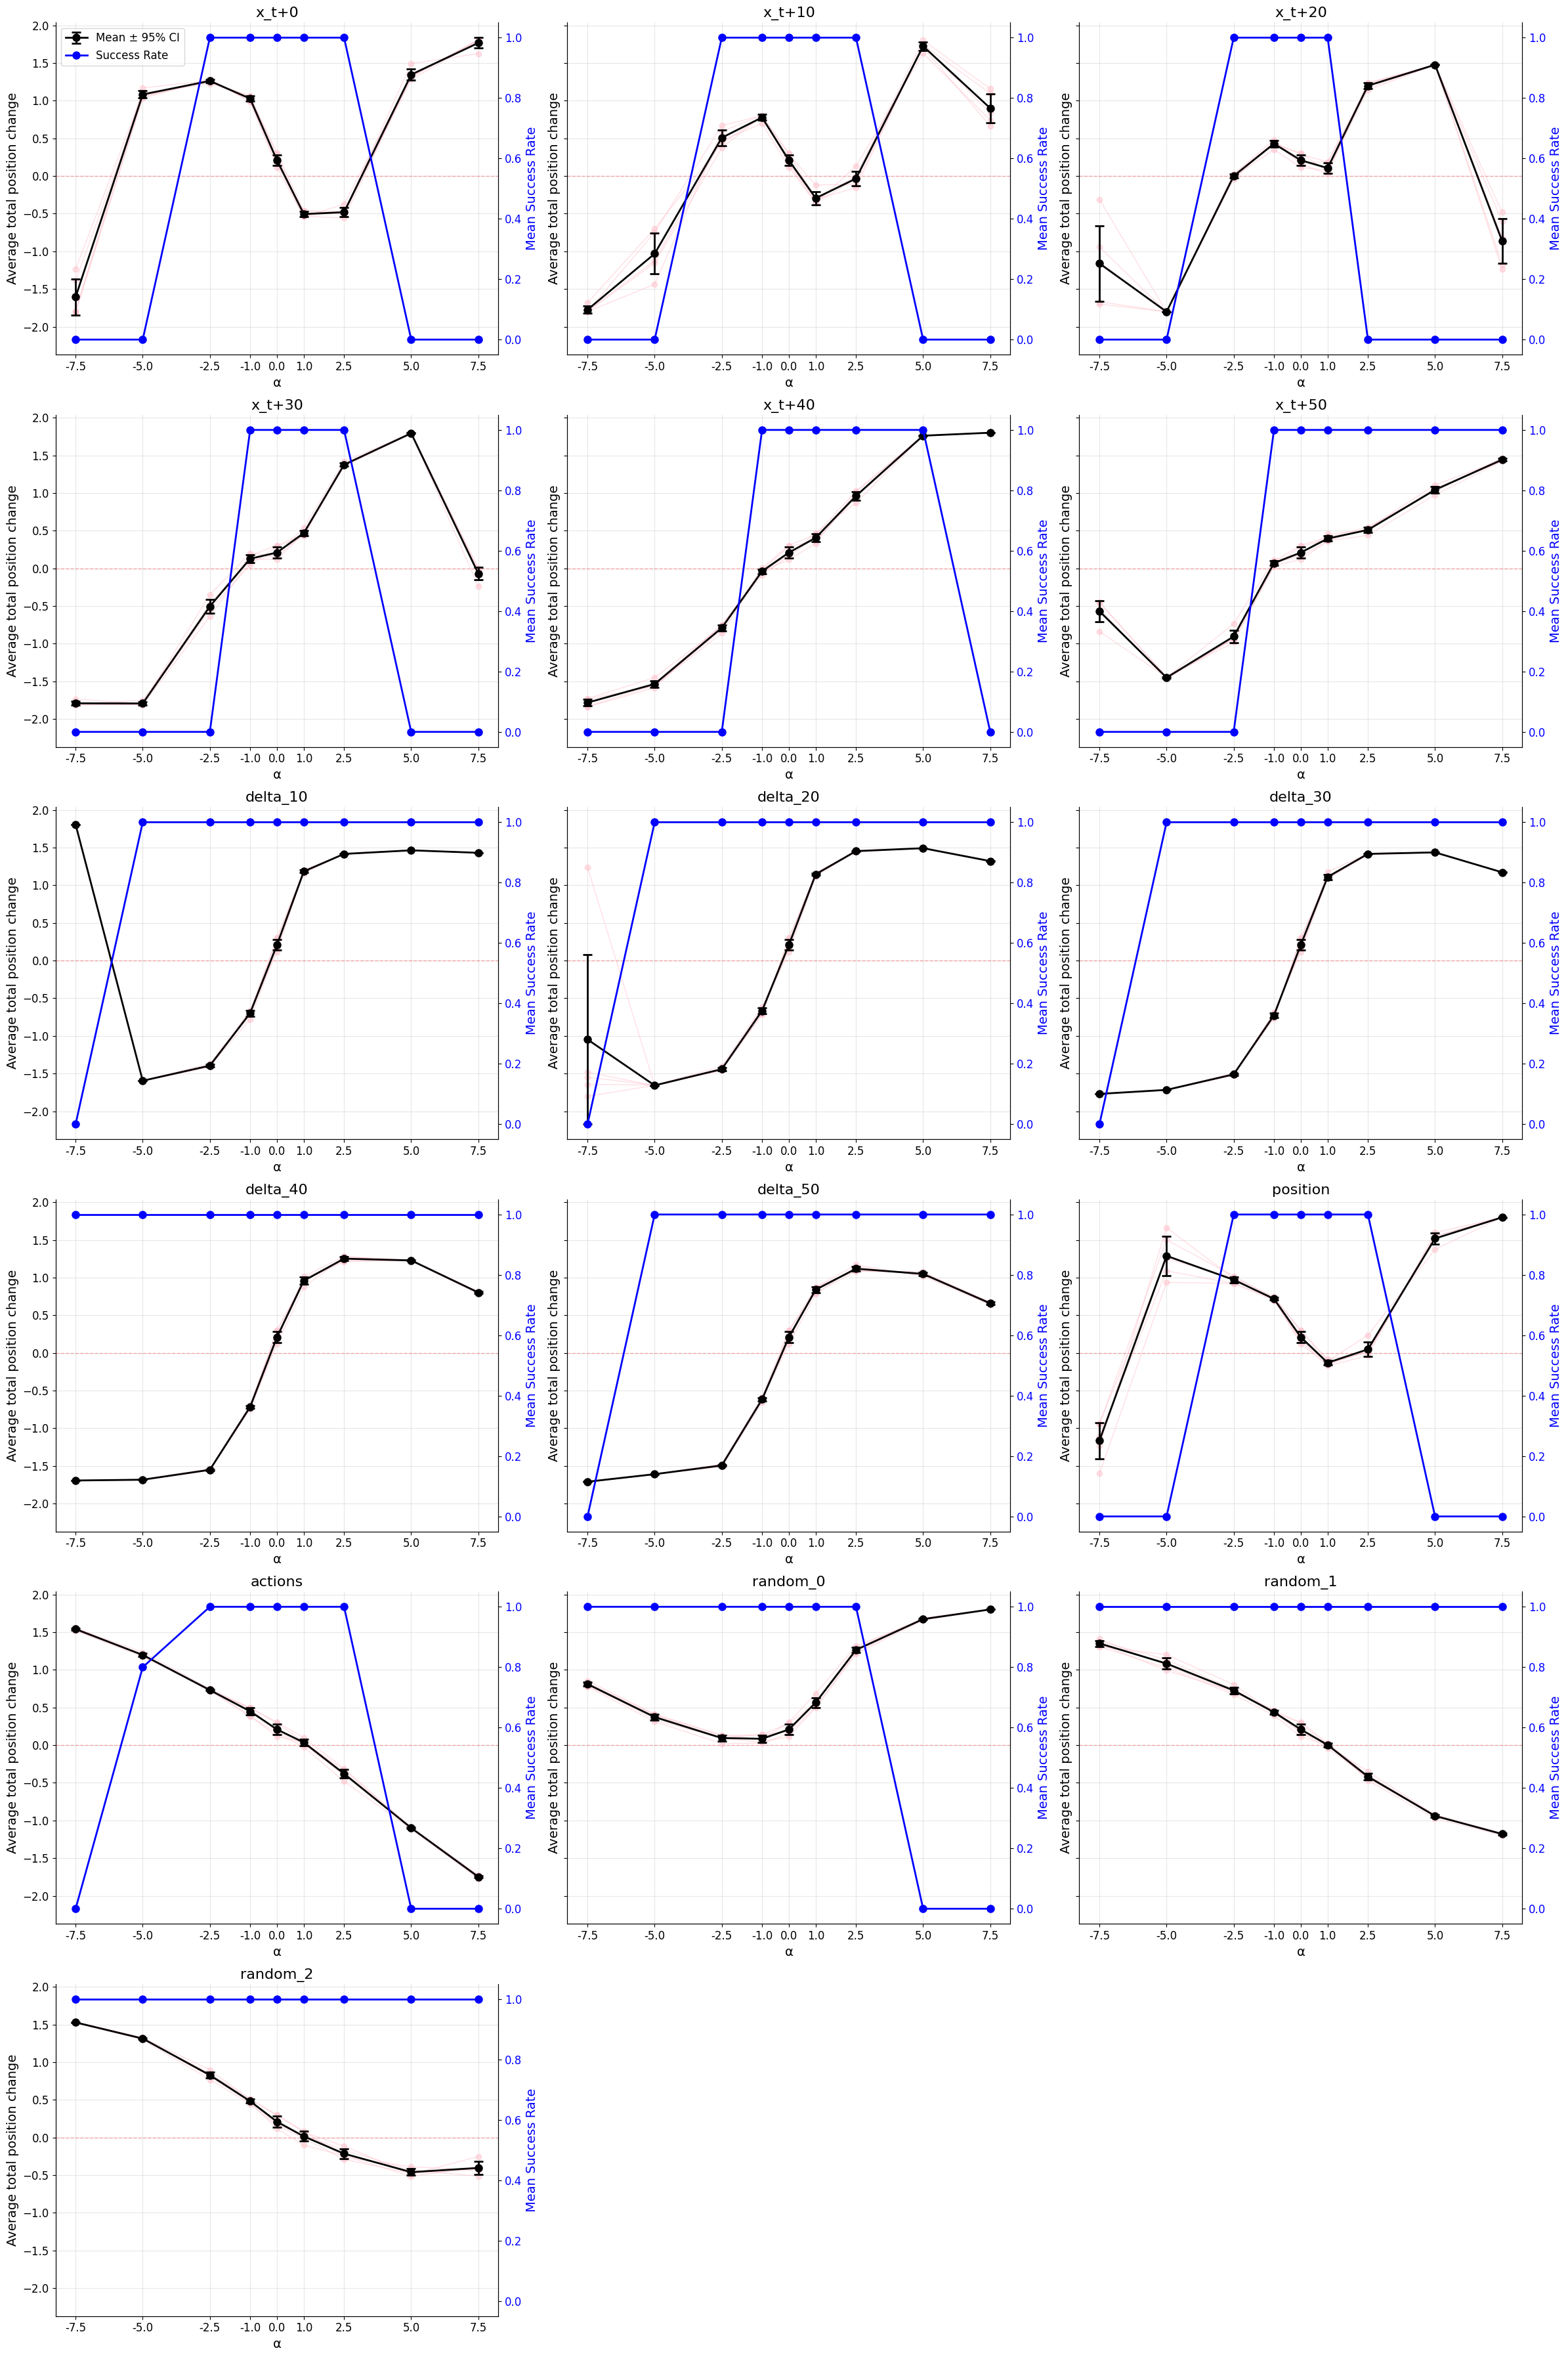

In [ ]:
# Get unique direction strings

direction_order = ['random_0', 'random_1', 'random_2']
direction_order = [
    'x_t+0', 'x_t+5', 'x_t+10', 'x_t+20', 'x_t+30', 'x_t+40', 'delta_5',
    'delta_10', 'delta_20', 'delta_30', 'delta_40', 'actions', 'random_0',
    'random_1', 'random_2'
]
direction_strs = direction_order
n_directions = len(direction_strs)
y_var = 'avg_vel_torso'

# Create subplots: 3 columns, calculate rows needed
n_cols = 3
n_rows = (n_directions + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows), sharey=True)
axes = axes.flatten() if n_directions > 1 else [axes]

for idx, direction_str in enumerate(direction_strs):
    ax1 = axes[idx]

    df_to_plot = df[df['config_direction_str'] == direction_str]

    # Group by alpha
    grouped = df_to_plot.groupby('config_magnitude')

    # Left y-axis:
    ax1.set_xlabel('α', fontsize=14)
    ax1.set_ylabel('Average total position change', fontsize=14)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # Plot one line per seed
    for seed in df_to_plot['config_seed'].unique():
        seed_data = df_to_plot[df_to_plot['config_seed'] == seed].sort_values(
            'config_magnitude')
        ax1.plot(seed_data['config_magnitude'],
                 seed_data[y_var],
                 color='pink',
                 marker='o',
                 alpha=0.5,
                 linewidth=1)

    # Plot mean with error bars (95% CI)
    alphas = []
    means = []
    ci_lower = []
    ci_upper = []

    for alpha, group in grouped:
        alphas.append(alpha)
        mean_val = group[y_var].mean()
        means.append(mean_val)
        std_val = group[y_var].std()
        n = len(group)
        ci = 1.96 * std_val / np.sqrt(n)  # 95% CI
        ci_lower.append(mean_val - ci)
        ci_upper.append(mean_val + ci)

    ax1.errorbar(alphas,
                 means,
                 yerr=[
                     np.array(means) - np.array(ci_lower),
                     np.array(ci_upper) - np.array(means)
                 ],
                 fmt='o-',
                 color='black',
                 linewidth=2,
                 markersize=8,
                 capsize=5,
                 capthick=2,
                 label='Mean ± 95% CI')

    ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    ax1.set_xticks(alphas)
    ax1.set_xticklabels([str(a) for a in alphas])
    ax1.grid(True, alpha=0.3)
    #ax1.set_ylim(-1.75, 1.75)

    # # Right y-axis: success rate
    # ax2 = ax1.twinx()
    # ax2.set_ylabel('Mean Success Rate', fontsize=14, color='blue')
    # ax2.set_ylim(-0.05, 1.05)

    # # Calculate success rate for each alpha
    # success_rates = []
    # for alpha, group in grouped:
    #     success_rate = group['success'].mean()
    #     success_rates.append(success_rate)

    # ax2.plot(alphas,
    #          success_rates,
    #          'o-',
    #          color='blue',
    #          linewidth=2,
    #          markersize=8,
    #          label='Success Rate')
    # ax2.tick_params(axis='y', labelcolor='blue', labelsize=12)

    # # Title
    # ax1.set_title(direction_str, fontsize=16)

    # Legend (only for first plot)
    if idx == 0:
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2,
                   labels1 + labels2,
                   loc='upper left',
                   fontsize=12)

# Hide any unused subplots
for idx in range(n_directions, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
sns.despine(top=True, right=False)
plt.show()


/scratch/slurm_tmpdir/job_1593629/ipykernel_3032522/750310589.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_latent_values,


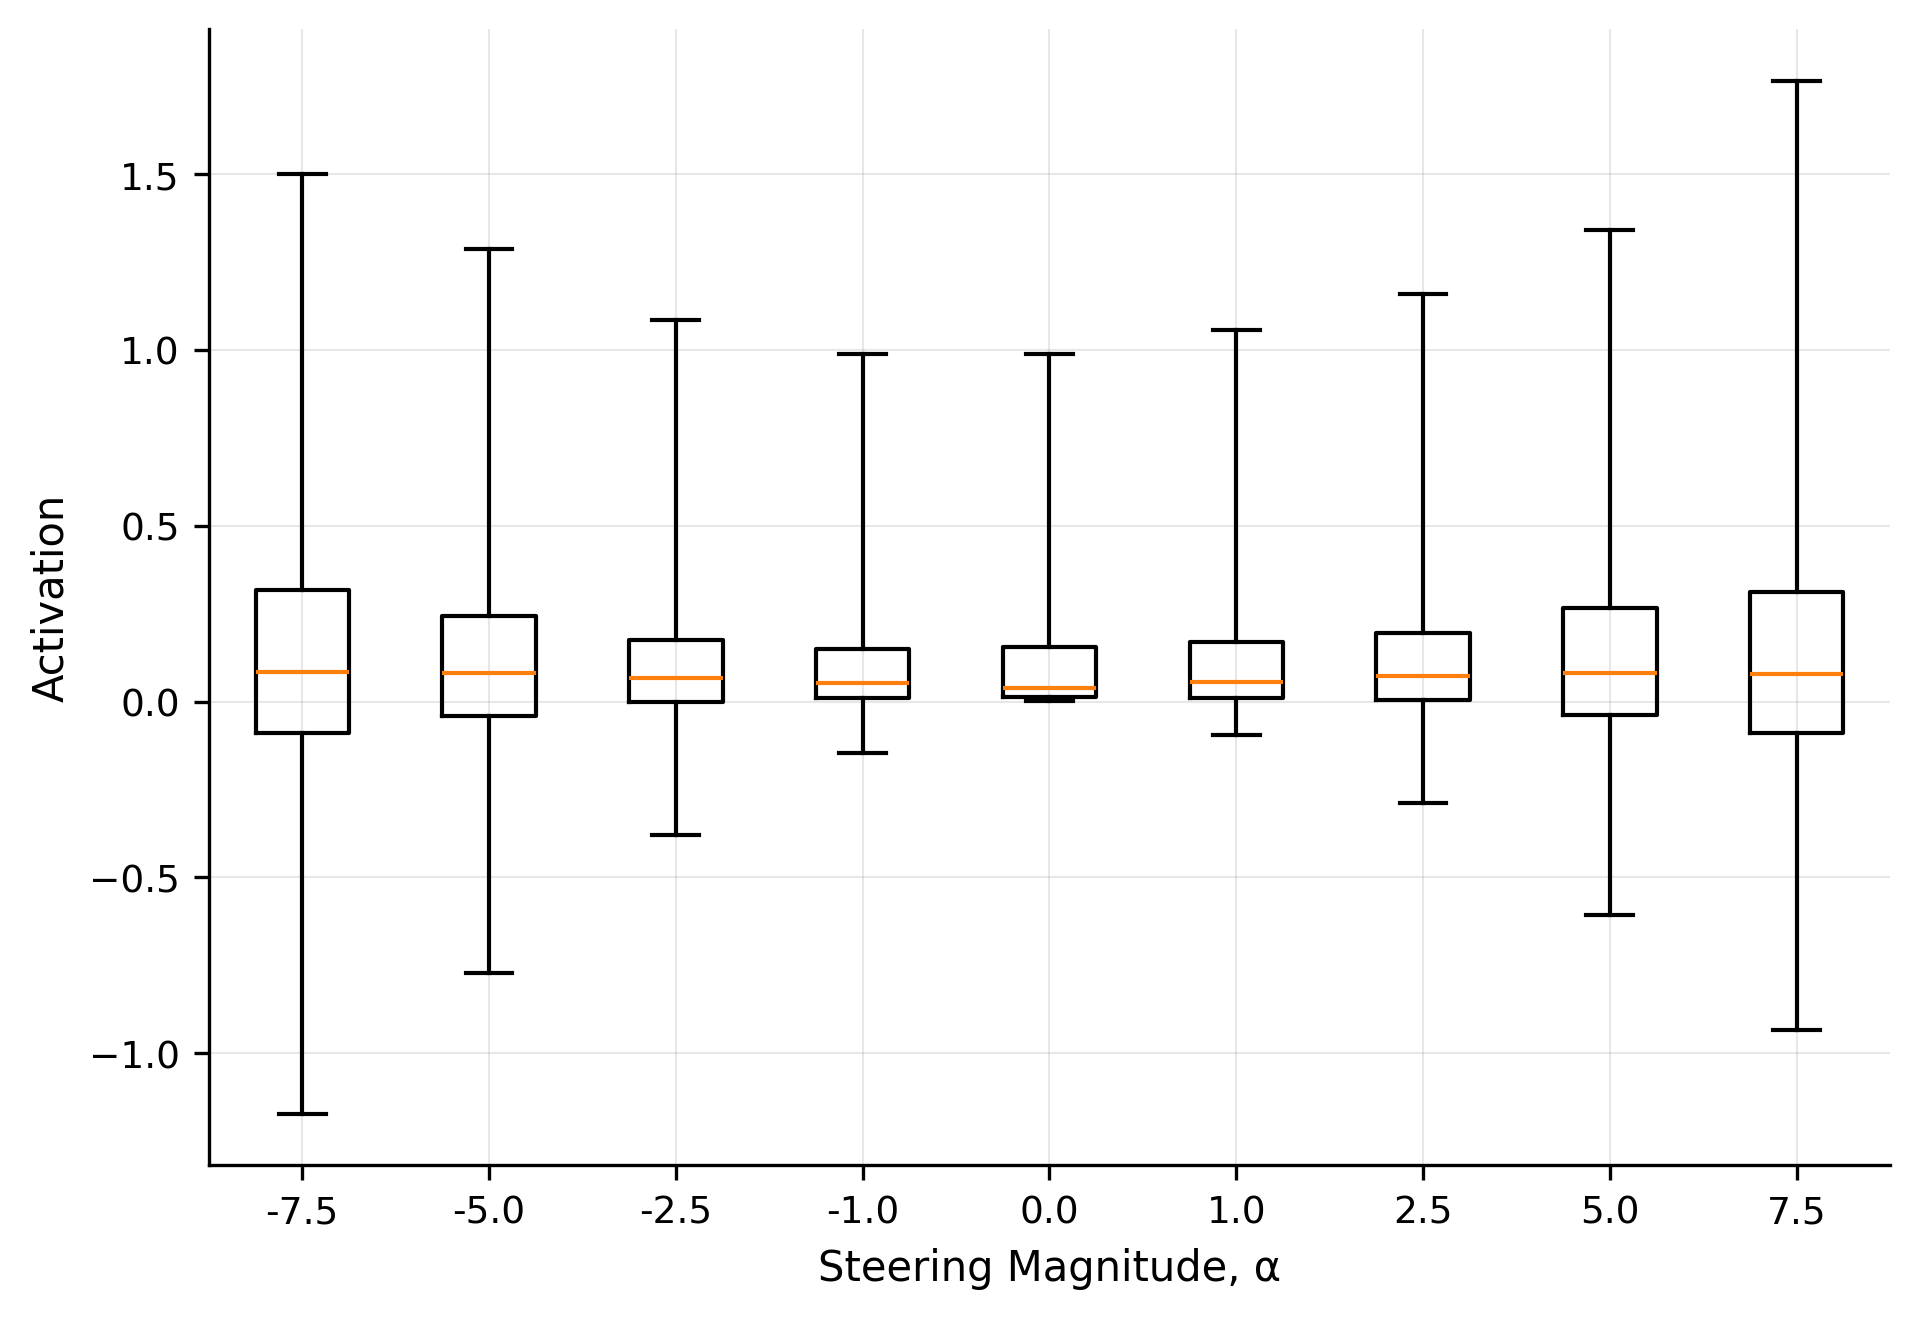

In [47]:
# Plot a boxplot of latent state values by magnitude, one plot for each lasso alpha
lasso_alphas_sorted = sorted(df['config_lasso_alpha'].unique())
magnitudes = sorted(df['config_magnitude'].unique())

df_to_plot = df[df['config_direction_str'] == 'w_action_lasso']
all_latent_values = []

for magnitude in magnitudes:
    # Get all latent states for this magnitude and lasso_alpha
    latent_states = df_to_plot[df_to_plot['config_magnitude'] ==
                               magnitude]['latent_states']

    # Flatten all latent states into a single list
    flattened = []
    for episode_latents in latent_states:
        flattened.extend(episode_latents.flatten())

    all_latent_values.append(flattened)

plt.figure(figsize=(6.5, 4.5), dpi=300)
plt.boxplot(all_latent_values,
            labels=magnitudes,
            showfliers=False,
            whis=[0, 100])
plt.xlabel('Steering Magnitude, α', fontsize=10)
plt.ylabel('Activation', fontsize=10)
plt.tick_params(axis='both', labelsize=9)
plt.grid(True, alpha=0.3, linewidth=0.5)
plt.tight_layout()
sns.despine()
plt.show()


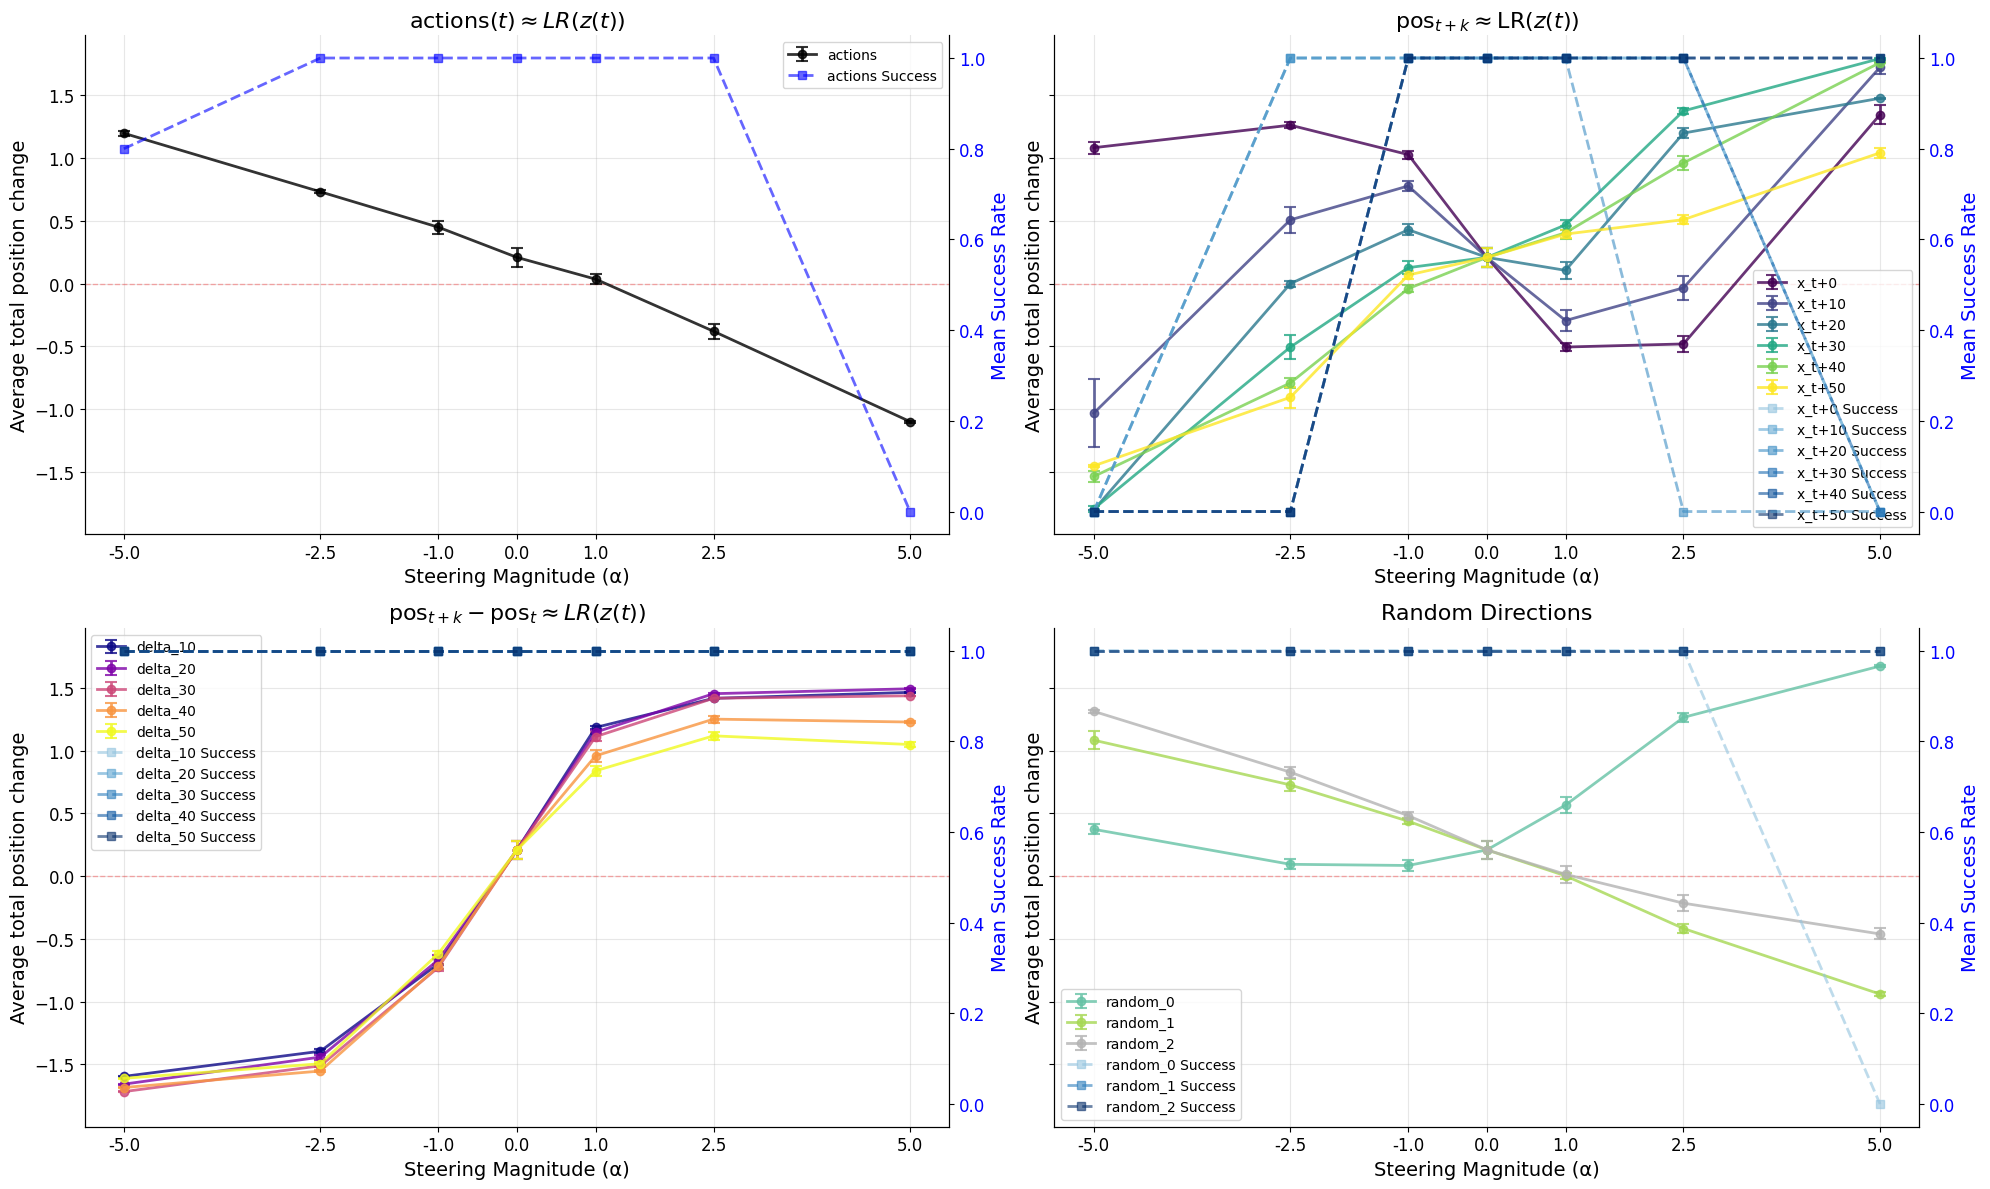

In [30]:
# Create 4 plots: actions, x_t+k, delta_k, random_i
y_var = 'total_position_change_midepisode'

# Define direction groups
direction_groups = {
    'actions': ['actions'],
    'x_t+k': ['x_t+0', 'x_t+10', 'x_t+20', 'x_t+30', 'x_t+40', 'x_t+50'],
    'delta_k': ['delta_10', 'delta_20', 'delta_30', 'delta_40', 'delta_50'],
    'random': ['random_0', 'random_1', 'random_2']
}

# Filter data to only include magnitudes between -5 and 5
df_filtered = df[(df['config_magnitude'] >= -5) & (df['config_magnitude'] <= 5)]

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

# Color palettes for each group
color_palettes = {
    'actions': ['black'],
    'x_t+k': plt.cm.viridis(np.linspace(0, 1, 6)),
    'delta_k': plt.cm.plasma(np.linspace(0, 1, 5)),
    'random': plt.cm.Set2(np.linspace(0, 1, 3))
}

# Blue color palettes for success rates
blue_palettes = {
    'actions': ['blue'],
    'x_t+k': plt.cm.Blues(np.linspace(0.4, 1, 6)),
    'delta_k': plt.cm.Blues(np.linspace(0.4, 1, 5)),
    'random': plt.cm.Blues(np.linspace(0.4, 1, 3))
}

plot_titles = [
    r'$\text{actions}(t) \approx LR(z(t))$',
    r'$\text{pos}_{t+k} \approx \text{LR}(z(t))$',
    r'$\text{pos}_{t+k} - \text{pos}_{t} \approx LR(z(t))$', 'Random Directions'
]

for plot_idx, (group_name, directions) in enumerate(direction_groups.items()):
    ax1 = axes[plot_idx]

    # Left y-axis setup
    ax1.set_xlabel('Steering Magnitude (α)', fontsize=14)
    ax1.set_ylabel('Average total position change', fontsize=14)
    ax1.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)

    # Get colors for this group
    colors = color_palettes[group_name]
    blue_colors = blue_palettes[group_name]

    # Plot each direction in the group
    for dir_idx, direction_str in enumerate(directions):
        df_to_plot = df_filtered[df_filtered['config_direction_str'] ==
                                 direction_str]

        if len(df_to_plot) == 0:
            continue

        # Group by magnitude
        grouped = df_to_plot.groupby('config_magnitude')

        # Calculate mean and CI
        alphas = []
        means = []
        ci_lower = []
        ci_upper = []

        for alpha, group in grouped:
            alphas.append(alpha)
            mean_val = group[y_var].mean()
            means.append(mean_val)
            std_val = group[y_var].std()
            n = len(group)
            ci = 1.96 * std_val / np.sqrt(n)  # 95% CI
            ci_lower.append(mean_val - ci)
            ci_upper.append(mean_val + ci)

        # Plot with error bars
        color = colors[dir_idx] if len(directions) > 1 else colors[0]
        ax1.errorbar(alphas,
                     means,
                     yerr=[
                         np.array(means) - np.array(ci_lower),
                         np.array(ci_upper) - np.array(means)
                     ],
                     fmt='o-',
                     color=color,
                     linewidth=2,
                     markersize=6,
                     capsize=4,
                     capthick=1.5,
                     label=direction_str,
                     alpha=0.8)

    # Set x-axis ticks to show all unique magnitudes
    unique_magnitudes = sorted(df_filtered['config_magnitude'].unique())
    ax1.set_xticks(unique_magnitudes)
    ax1.set_xticklabels([str(m) for m in unique_magnitudes])

    ax1.tick_params(axis='y', labelcolor='black', labelsize=12)
    ax1.tick_params(axis='x', labelsize=12)
    ax1.grid(True, alpha=0.3)
    # Right y-axis: success rate (plot for all directions in group)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Mean Success Rate', fontsize=14, color='blue')
    ax2.set_ylim(-0.05, 1.05)

    # Plot success rate for each direction
    for dir_idx, direction_str in enumerate(directions):
        df_to_plot = df_filtered[df_filtered['config_direction_str'] ==
                                 direction_str]

        if len(df_to_plot) == 0:
            continue

        grouped = df_to_plot.groupby('config_magnitude')

        alphas = []
        success_rates = []
        for alpha, group in grouped:
            alphas.append(alpha)
            success_rate = group['success'].mean()
            success_rates.append(success_rate)

        # Use different shades of blue for success rates
        blue_color = blue_colors[dir_idx] if len(
            directions) > 1 else blue_colors[0]
        ax2.plot(alphas,
                 success_rates,
                 's--',
                 color=blue_color,
                 linewidth=2,
                 markersize=6,
                 label=f'{direction_str} Success',
                 alpha=0.6)

    ax2.tick_params(axis='y', labelcolor='blue', labelsize=12)

    # Title
    ax1.set_title(plot_titles[plot_idx], fontsize=16)

    # Legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=10)

plt.tight_layout()
sns.despine(top=True, right=False)
plt.show()
